In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class SARBacktester():
    def __init__(self, symbol, start_af=0.02, max_af=0.2, start=None, end=None):
        self.symbol = symbol
        self.start_af = start_af
        self.max_af = max_af
        self.start = start
        self.end = end
        self.results = None
        self.get_data()
        
    def get_data(self):
        df = yf.download(self.symbol, start=self.start, end=self.end)[['High', 'Low', 'Close']]
        data = df.copy()
        data["returns"] = np.log(data.Close.div(data.Close.shift(1)))
        
        # Calculate SAR indicator
        data = self.calculate_sar(data)
        
        data.dropna(inplace=True)
        self.data2 = data
        return data
    
    def calculate_sar(self, data):
        """Calculate Parabolic SAR indicator"""
        high = data['High'].values
        low = data['Low'].values
        close = data['Close'].values
        
        # Initialize arrays
        sar = np.zeros(len(data))
        trend = np.zeros(len(data))  # 1 for uptrend, -1 for downtrend
        af = np.zeros(len(data))
        ep = np.zeros(len(data))  # Extreme point
        
        # Initial values
        sar[0] = low[0]
        trend[0] = 1  # Assume initial uptrend
        af[0] = self.start_af
        ep[0] = high[0]
        
        for i in range(1, len(data)):
            # Previous period values
            prev_sar = sar[i-1]
            prev_trend = trend[i-1]
            prev_af = af[i-1]
            prev_ep = ep[i-1]
            
            # Calculate current SAR
            sar[i] = prev_sar + prev_af * (prev_ep - prev_sar)
            
            # Check for trend reversal
            if prev_trend == 1:  # Previous uptrend
                if low[i] <= sar[i]:  # Price breaks below SAR, trend reversal
                    trend[i] = -1
                    sar[i] = prev_ep  # SAR becomes previous high
                    af[i] = self.start_af
                    ep[i] = low[i]
                else:  # Trend continues
                    trend[i] = 1
                    if high[i] > prev_ep:  # New high
                        ep[i] = high[i]
                        af[i] = min(prev_af + self.start_af, self.max_af)
                    else:
                        ep[i] = prev_ep
                        af[i] = prev_af
                    
                    # SAR cannot be higher than the lowest low of previous two periods
                    if i >= 2:
                        sar[i] = min(sar[i], low[i-1], low[i-2])
                    else:
                        sar[i] = min(sar[i], low[i-1])
                        
            else:  # Previous downtrend
                if high[i] >= sar[i]:  # Price breaks above SAR, trend reversal
                    trend[i] = 1
                    sar[i] = prev_ep  # SAR becomes previous low
                    af[i] = self.start_af
                    ep[i] = high[i]
                else:  # Trend continues
                    trend[i] = -1
                    if low[i] < prev_ep:  # New low
                        ep[i] = low[i]
                        af[i] = min(prev_af + self.start_af, self.max_af)
                    else:
                        ep[i] = prev_ep
                        af[i] = prev_af
                    
                    # SAR cannot be lower than the highest high of previous two periods
                    if i >= 2:
                        sar[i] = max(sar[i], high[i-1], high[i-2])
                    else:
                        sar[i] = max(sar[i], high[i-1])
        
        data['SAR'] = sar
        data['SAR_Trend'] = trend
        data['SAR_AF'] = af
        data['SAR_EP'] = ep
        
        return data
    
    def test_results(self):
        data = self.data2.copy().dropna()
        
        data["position"] = 0
        
        # Convert to numpy arrays for faster processing
        positions = data["position"].values
        trends = data["SAR_Trend"].values
        closes = data["Close"].values
        sars = data["SAR"].values
        
        for i in range(1, len(data)):
            prev_position = positions[i-1]
            
            current_trend = trends[i]
            prev_trend = trends[i-1]
            
            current_close = closes[i]
            current_sar = sars[i]
            
            # Buy signal: SAR moves from above price to below price (trend changes from -1 to 1)
            if prev_trend == -1 and current_trend == 1 and prev_position == 0:
                positions[i] = 1
            
            # Close signal: price touches SAR (price breaks below SAR when holding long)
            elif prev_position == 1:
                if current_close <= current_sar:  # Price touches or breaks below SAR
                    positions[i] = 0
                else:
                    positions[i] = 1
            else:
                positions[i] = 0
        
        # Update the dataframe with the new positions
        data["position"] = positions
        
        data["strategy"] = data["returns"] * data.position.shift(1)
        data.dropna(inplace=True)
        
        data["returnsbh"] = data["returns"].cumsum().apply(np.exp)
        data["returnsstrategy"] = data["strategy"].cumsum().apply(np.exp)
        
        perf = data["returnsstrategy"].iloc[-1]
        outperf = perf - data["returnsbh"].iloc[-1]
        
        self.results = data
        return round(perf, 6), round(outperf, 6)
    
    def plot_results(self):
        if self.results is None:
            print("Run the test please")
        else:
            title = "{} | SAR({},{})".format(self.symbol, self.start_af, self.max_af)
            self.results[["returnsbh", "returnsstrategy"]].plot(title=title, figsize=(12, 8))
            plt.show()
    
    def plot_sar(self):
        data = self.data2.copy()
        
        fig, ax = plt.subplots(1, 1, figsize=(14, 8))
        
        # Plot stock price
        ax.plot(data.index, data.Close, label='Close Price', linewidth=1, color='blue')
        
        # Plot SAR dots
        # Green dots for uptrend (SAR below price)
        uptrend_mask = data['SAR_Trend'] == 1
        ax.scatter(data.index[uptrend_mask], data.SAR[uptrend_mask], 
                  color='green', s=20, label='SAR (Uptrend)', alpha=0.7)
        
        # Red dots for downtrend (SAR above price)
        downtrend_mask = data['SAR_Trend'] == -1
        ax.scatter(data.index[downtrend_mask], data.SAR[downtrend_mask], 
                  color='red', s=20, label='SAR (Downtrend)', alpha=0.7)
        
        ax.set_title(f"{self.symbol} Price and SAR({self.start_af},{self.max_af})", fontsize=15)
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def plot_signals(self):
        if self.results is None:
            print("Run the test please")
            return
            
        data = self.results.copy()
        
        fig, ax = plt.subplots(1, 1, figsize=(14, 8))
        
        # Plot stock price
        ax.plot(data.index, data.Close, label='Close Price', linewidth=1, color='blue')
        
        # Plot SAR dots
        uptrend_mask = data['SAR_Trend'] == 1
        ax.scatter(data.index[uptrend_mask], data.SAR[uptrend_mask], 
                  color='green', s=15, alpha=0.5)
        
        downtrend_mask = data['SAR_Trend'] == -1
        ax.scatter(data.index[downtrend_mask], data.SAR[downtrend_mask], 
                  color='red', s=15, alpha=0.5)
        
        # Buy signals
        buy_signals = data[data.position.diff() == 1]
        ax.scatter(buy_signals.index, buy_signals.Close, color='green', 
                   marker='^', s=100, label='Buy Signal', zorder=5)
        
        # Sell signals (close position)
        sell_signals = data[data.position.diff() == -1]
        ax.scatter(sell_signals.index, sell_signals.Close, color='red', 
                   marker='v', s=100, label='Sell Signal', zorder=5)
        
        ax.set_title(f"{self.symbol} SAR Trading Signals", fontsize=15)
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def get_trade_summary(self):
        if self.results is None:
            print("Run the test please")
            return
            
        data = self.results.copy()
        
        position_changes = data.position.diff().fillna(0)
        long_entries = len(position_changes[position_changes == 1])
        
        strategy_returns = data["strategy"].dropna()
        bh_returns = data["returns"].dropna()
        total_trades = long_entries
        winning_trades = len(strategy_returns[strategy_returns > 0])
        losing_trades = len(strategy_returns[strategy_returns < 0])
        
        if total_trades > 0:
            win_rate = winning_trades / len(strategy_returns[strategy_returns != 0]) * 100
        else:
            win_rate = 0
            
        print(f"Total trades: {total_trades}")
        print(f"Long trades: {long_entries}")
        print(f"Win rate: {win_rate:.2f}%")
        print(f"Average daily return: {strategy_returns.mean():.4f}")
        print(f"Return std: {strategy_returns.std():.4f}")
        
        # Calculate Sharpe Ratio
        # Assuming risk-free rate is 0 for simplicity, can be adjusted
        risk_free_rate = 0.0
        
        # Strategy Sharpe Ratio
        if strategy_returns.std() != 0:
            strategy_sharpe = (strategy_returns.mean() - risk_free_rate) / strategy_returns.std()
            # Annualize the Sharpe ratio (multiply by sqrt(252) for daily data)
            strategy_sharpe_annualized = strategy_sharpe * np.sqrt(252)
        else:
            strategy_sharpe_annualized = 0
            
        # Buy-and-Hold Sharpe Ratio
        if bh_returns.std() != 0:
            bh_sharpe = (bh_returns.mean() - risk_free_rate) / bh_returns.std()
            # Annualize the Sharpe ratio
            bh_sharpe_annualized = bh_sharpe * np.sqrt(252)
        else:
            bh_sharpe_annualized = 0
        
        print(f"\n=== Sharpe Ratio Analysis ===")
        print(f"Strategy Sharpe Ratio (annualized): {strategy_sharpe_annualized:.4f}")
        print(f"Buy-and-Hold Sharpe Ratio (annualized): {bh_sharpe_annualized:.4f}")
        print(f"Sharpe Ratio Difference: {(strategy_sharpe_annualized - bh_sharpe_annualized):.4f}")
        
        # Display final performance
        if len(data) > 0:
            final_strategy_return = data["returnsstrategy"].iloc[-1]
            final_bh_return = data["returnsbh"].iloc[-1]
            print(f"\n=== Performance Summary ===")
            print(f"Final strategy return: {final_strategy_return:.4f}")
            print(f"Final buy-and-hold return: {final_bh_return:.4f}")
            print(f"Outperformance: {(final_strategy_return - final_bh_return):.4f}")
            
        # Calculate maximum drawdown
        cumulative_returns = (1 + strategy_returns).cumprod()
        running_max = cumulative_returns.expanding().max()
        drawdown = (cumulative_returns - running_max) / running_max
        max_drawdown = drawdown.min()
        
        print(f"Maximum Drawdown: {max_drawdown:.4f} ({max_drawdown*100:.2f}%)")
        
        # Calculate Calmar Ratio (Annual Return / Max Drawdown)
        annual_return = strategy_returns.mean() * 252
        if max_drawdown != 0:
            calmar_ratio = annual_return / abs(max_drawdown)
        else:
            calmar_ratio = 0
        print(f"Calmar Ratio: {calmar_ratio:.4f}")
        
        return {
            'total_trades': total_trades,
            'win_rate': win_rate,
            'strategy_sharpe': strategy_sharpe_annualized,
            'bh_sharpe': bh_sharpe_annualized,
            'max_drawdown': max_drawdown,
            'calmar_ratio': calmar_ratio,
            'final_strategy_return': final_strategy_return,
            'final_bh_return': final_bh_return
        }

In [13]:
sar_test = SARBacktester("QQQ", start_af=0.02, max_af=0.2, 
                            start="2025-04-01", end="2025-07-09")

/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_49158/881065912.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.symbol, start=self.start, end=self.end)[['High', 'Low', 'Close']]
[*********************100%***********************]  1 of 1 completed
/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_49158/881065912.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sar[0] = low[0]
/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_49158/881065912.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ep[0] = high[0]
/var/folders/4z/0p4c7jt52_d1bq34q6bc_x8

In [14]:
sar_test.get_data()

/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_49158/881065912.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.symbol, start=self.start, end=self.end)[['High', 'Low', 'Close']]
[*********************100%***********************]  1 of 1 completed
/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_49158/881065912.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sar[0] = low[0]
/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_49158/881065912.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ep[0] = high[0]
/var/folders/4z/0p4c7jt52_d1bq34q6bc_x8

Price,High,Low,Close,returns,SAR,SAR_Trend,SAR_AF,SAR_EP
Ticker,QQQ,QQQ,QQQ,,,,,
Date,,,,,,,,
2025-04-02,479.022023,465.337380,475.615845,0.007272,463.899028,1.0,0.04,479.022023
2025-04-03,459.553897,449.635044,450.154449,-0.055020,479.022023,-1.0,0.02,449.635044
2025-04-04,439.875988,422.195862,422.195862,-0.064121,479.022023,-1.0,0.04,422.195862
2025-04-07,442.642884,401.938598,423.214691,0.002410,476.748977,-1.0,0.06,401.938598
2025-04-08,442.642900,409.330306,415.593262,-0.018173,472.260354,-1.0,0.06,401.938598
...,...,...,...,...,...,...,...,...
2025-07-01,550.710022,544.659973,546.989990,-0.008465,530.217200,1.0,0.10,552.799988
2025-07-02,551.000000,546.119995,550.799988,0.006941,532.475479,1.0,0.10,552.799988


In [15]:
sar_test.test_results()

(1.167238, 0.005922)

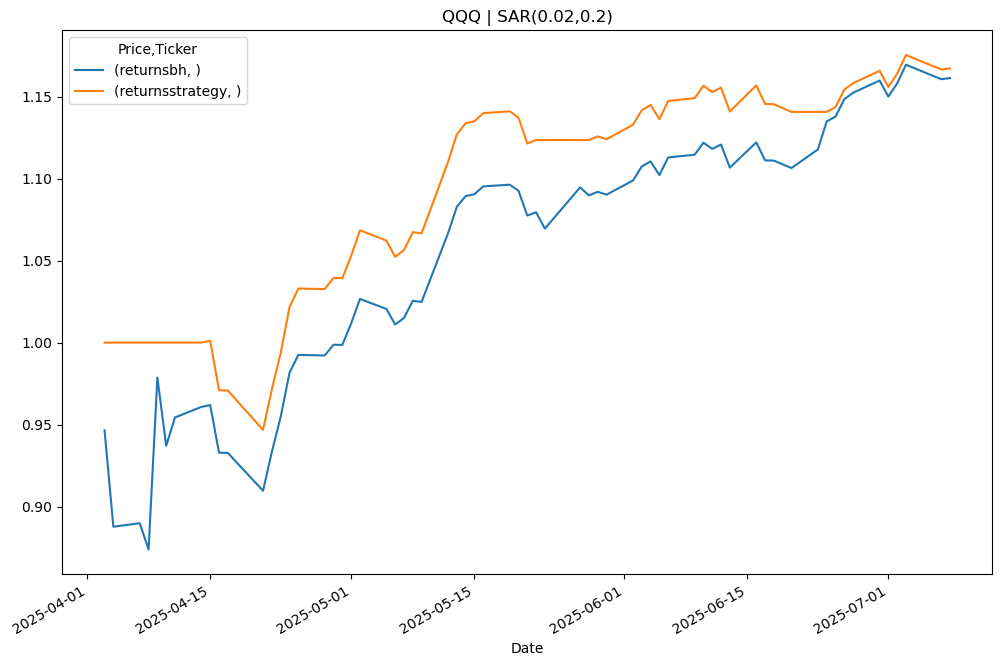

In [16]:
sar_test.plot_results()

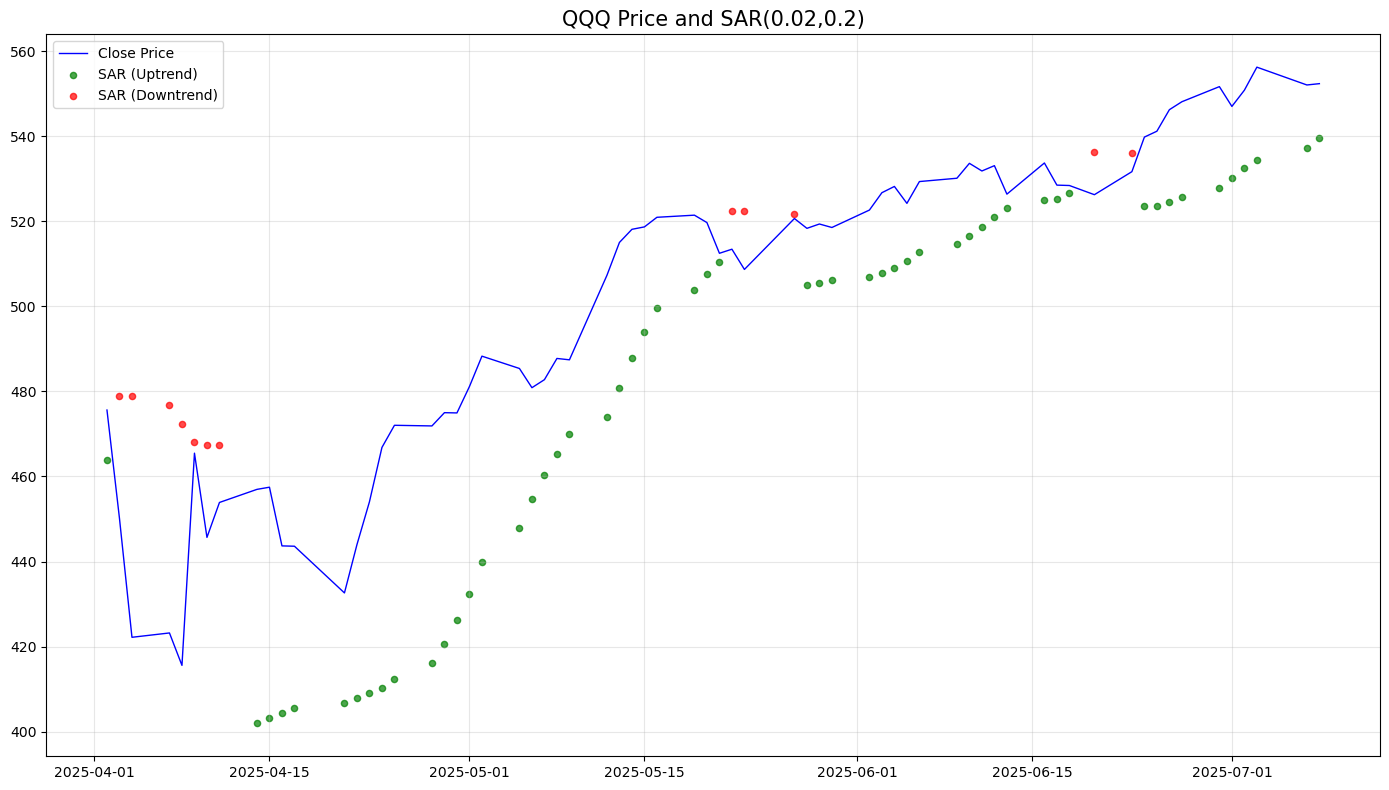

In [17]:
sar_test.plot_sar()

In [18]:
sar_test.get_trade_summary()

Total trades: 3
Long trades: 3
Win rate: 63.46%
Average daily return: 0.0024
Return std: 0.0107

=== Sharpe Ratio Analysis ===
Strategy Sharpe Ratio (annualized): 3.5451
Buy-and-Hold Sharpe Ratio (annualized): 1.6633
Sharpe Ratio Difference: 1.8818

=== Performance Summary ===
Final strategy return: 1.1672
Final buy-and-hold return: 1.1613
Outperformance: 0.0059
Maximum Drawdown: -0.0551 (-5.51%)
Calmar Ratio: 10.8850


{'total_trades': 3,
 'win_rate': 63.46153846153846,
 'strategy_sharpe': 3.545123814745718,
 'bh_sharpe': 1.6632799512445142,
 'max_drawdown': -0.0550784948144353,
 'calmar_ratio': 10.88495375870267,
 'final_strategy_return': 1.1672375247027023,
 'final_bh_return': 1.1613154460255968}